In [1]:
import warnings
warnings.filterwarnings('ignore',category=RuntimeWarning)
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import glob,os,sys
from tqdm.auto import tqdm
import proplot as plot
import json,pickle
import dask.array as da
import gc
from tools import derive_var,read_and_proc,preproc_noensemble
from tools.mlr import mlr
from tools.preprocess import do_eof,preproc_maria,preproc_haiyan
from tqdm.auto import tqdm
sys.path.insert(1, '../')
import read_stuff as read
import torch
from torch.utils.data import DataLoader, TensorDataset
import vae3d
from vae3d import VAEEncoder, VAEDecoder, VAE, elbo_loss
import optuna
import torch.nn.functional as F
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import math
import data_process
import random
import preproc_decomp
plot.rc.update({'figure.facecolor':'w','axes.labelweight':'ultralight',
                'tick.labelweight':'ultralight','gridminor.linestyle':'--','title.weight':'normal','linewidth':0.5})
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:32"

/tmp/ipykernel_3229453/2301260017.py:33: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({'figure.facecolor':'w','axes.labelweight':'ultralight',


In [3]:
device = 'cpu'
folds = data_process.setup_folds(n_numbers=20,indepedent_test={10,17},val_size=4,seed=42)
lassoalpha=0.1
num_rad=5

Fold 1: validation members = [4, 9, 13, 14]
Fold 2: validation members = [5, 6, 7, 18]
Fold 3: validation members = [1, 11, 12, 16]
Fold 4: validation members = [2, 8, 15, 19]
Fold 5: validation members = [0, 3, 13, 14]


## Figures to check the results for one (lassoalpha,num_rad) pair

In [4]:
results = read_and_proc.depickle(f'./newproc/directC/lasso_alpha{lassoalpha}_nr{num_rad}_performance.pkl')

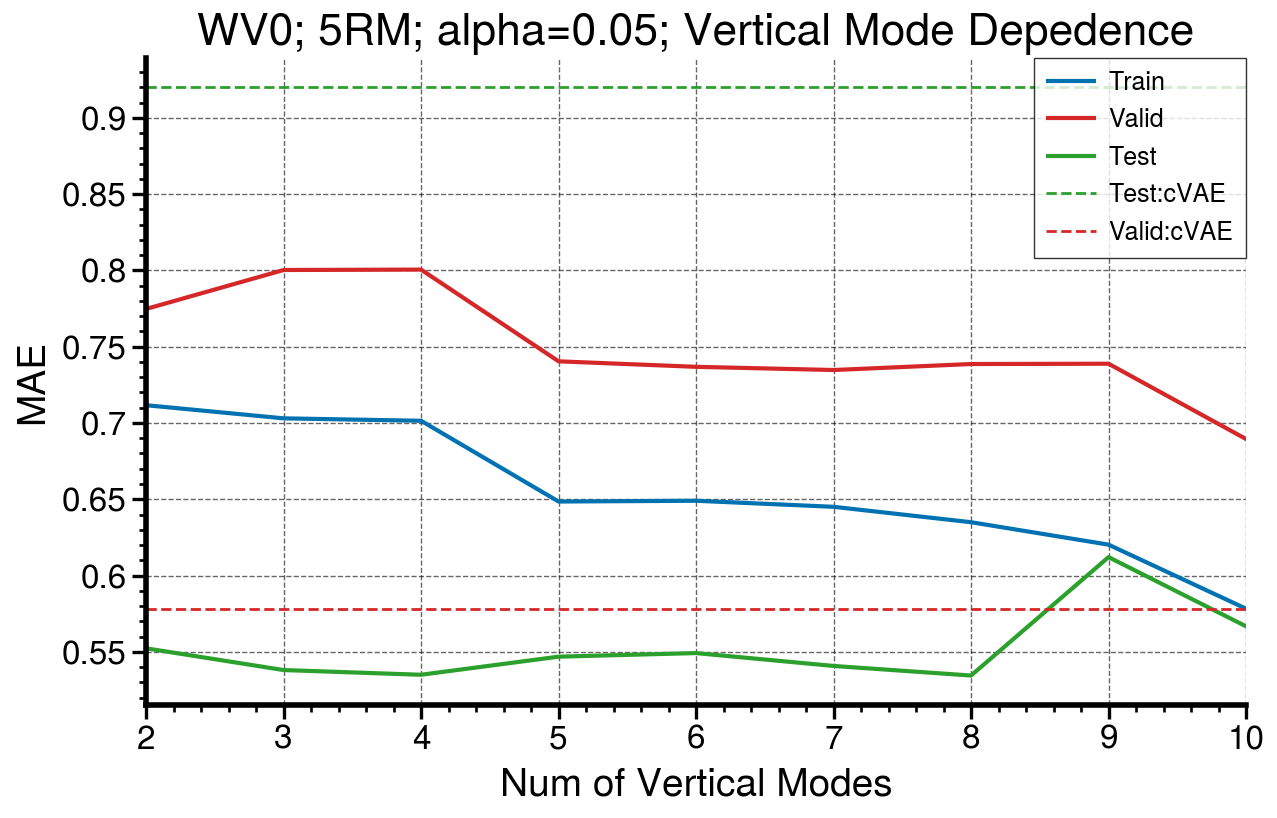

In [20]:
fig, ax = plot.subplots(refwidth=5.5, refaspect=1.7)
ax.plot([2,3,4,5,6,7,8,9,10],[np.asarray([d['MAE'] for d in results['train'][num_rad][numv]]).mean() for numv in [2,3,4,5,6,7,8,9,10]],label='Train')
ax.plot([2,3,4,5,6,7,8,9,10],[np.asarray([d['MAE'] for d in results['valid'][num_rad][numv]]).mean() for numv in [2,3,4,5,6,7,8,9,10]],label='Valid',c='tab:red')
ax.plot([2,3,4,5,6,7,8,9,10],[np.asarray([d['MAE'] for d in results['test'][num_rad][numv]]).mean() for numv in [2,3,4,5,6,7,8,9,10]],label='Test',c='tab:green')

ax.axhline(y=0.9199999999999999,lw=1,ls='--',c='tab:green',label='Test:cVAE')
ax.axhline(y=0.5780000000000001,lw=1,ls='--',c='tab:red',label='Valid:cVAE')
# Style & labels (ProPlot uses similar syntax to matplotlib)
ax.format(
    xlabel='Num of Vertical Modes',
    ylabel='MAE',
    title=f'WV0; {num_rad}RM; alpha=0.05; Vertical Mode Depedence',
    xlabelsize=14,
    ylabelsize=14,
    titlesize=16,
    ticklabelsize=12,
    grid=True,
    gridstyle='--',
    gridalpha=0.6,
    ticklen=5,
    tickwidth=1.2
)

# Optional: hide top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Make top and left spines thicker
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
# Legend
ax.legend(fontsize=12,ncols=1)
plt.show()

## Summarize complexity statistics for joint optimization

In [4]:
import pandas as pd

def get_complexities(TYPE='test',metric='MAE',lassoalpha=0.1):
    complexities = []
    num_rads = []
    num_verts = []
    for num_rad in [2,3,4,5,6,7,8,9,10]:
        results = read_and_proc.depickle(f'./newproc/directC/lasso_alpha{lassoalpha}_nr{num_rad}_performance.pkl')
        tempdict = {num_rad+numv: np.asarray([d[metric] for d in results[TYPE][num_rad][numv]]).mean() for numv in [2,3,4,5,6,7,8,9,10]}
        num_rads = [num_rad for _ in [2,3,4,5,6,7,8,9,10]]
        num_verts = [numv for numv in [2,3,4,5,6,7,8,9,10]]
        complexities.append(pd.DataFrame({'featurenum':list(tempdict.keys()),'metric':list(tempdict.values()),'numrad':num_rads,'numvert':num_verts}))
    return complexities

def is_pareto_efficient(costs):
    """
    Returns a boolean array indicating whether each point is Pareto efficient.
    'costs' is an (n_points, n_costs) array, where lower values are better.
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            # Remove dominated points
            is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1) | np.all(costs[is_efficient] == c, axis=1)
            is_efficient[i] = True  # keep self
    return is_efficient

In [5]:
complexities_test = pd.concat(get_complexities('test','MAE',0.1)).reset_index()
complexities_valid = pd.concat(get_complexities('valid','MAE',0.1)).reset_index()

### Find Pareto Optimal models based on validation set

In [6]:
# Apply to your data
costs = complexities_valid[['featurenum', 'metric']].values
pareto_mask = is_pareto_efficient(costs)

pareto_df = complexities_valid[pareto_mask]

In [8]:
# Obtain the best model
model_numrad, model_numvert = pareto_df['numrad'].iloc[2], pareto_df['numvert'].iloc[2]
models = read_and_proc.depickle(f'./newproc/directC/lasso_alpha{lassoalpha}_nr{model_numrad}_performance.pkl')['model'][model_numrad][model_numvert]

In [15]:
y_target = read_and_proc.depickle(f'./newproc/directC/lasso_alpha{lassoalpha}_nr{model_numrad}_performance.pkl')['y'][model_numrad][model_numvert][0]['test'].squeeze().max()

In [19]:
models[0].intercept_

array([-1.23099898e-09])

In [22]:
calculate_optimal_input_coefficients(y_target, models[0].coef_, models[0].intercept_)

array([ 0.        , -0.        ,  2.53152364,  0.        ,  0.        ,
        2.02981755, -0.        ,  2.45545118, -0.        ,  3.71605949])

### Find corresponding test skills

In [23]:
pareto_test = complexities_test.iloc[pareto_df.index]

In [24]:
pareto_df

,index,featurenum,metric,numrad,numvert
0,0,4,0.802238,2,2
9,0,5,0.792380,3,2
27,0,7,0.774721,5,2
36,0,8,0.741066,6,2
45,0,9,0.736979,7,2
54,0,10,0.700072,8,2
57,3,13,0.674613,8,5
62,8,18,0.662760,8,10
80,8,20,0.647313,10,10


ERROR! Session/line number was not unique in database. History logging moved to new session 6537


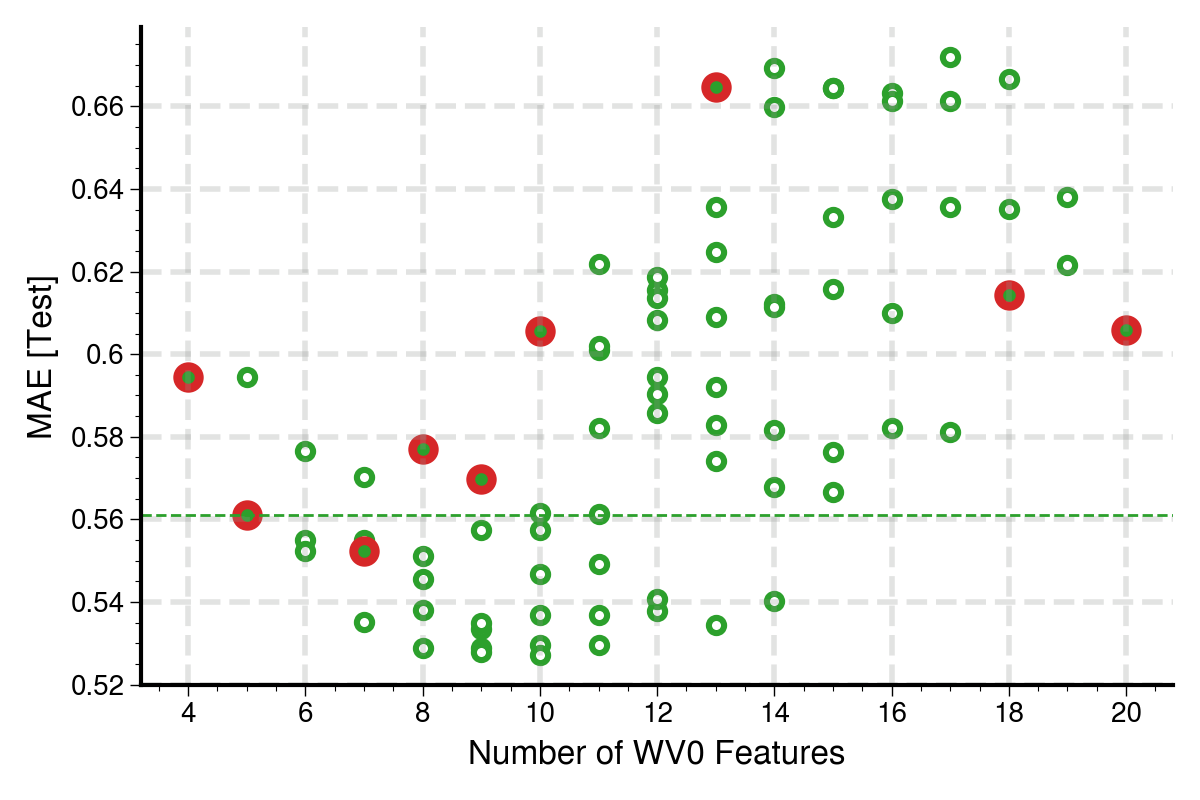

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(
    complexities_test['featurenum'],
    complexities_test['metric'],
    facecolors='white',
    edgecolors='tab:green',
    s=30,
    linewidth=2.2
)
#ax.axhline(y=0.581,lw=1,ls='--',c='tab:red',label='Valid:cVAE')
ax.axhline(y=0.561,lw=1,ls='--',c='tab:green',label='Test:cVAE')
ax.scatter(pareto_test['featurenum'],pareto_test['metric'],
           facecolors='tab:green',
           edgecolors='tab:red',
           s=60,
           linewidth=3.2)
# Improve axis labels and style
ax.set_xlabel('Number of WV0 Features', fontsize=12)
ax.set_ylabel('MAE [Test]', fontsize=12)
#ax.set_title('Feature Complexity vs. Metric', fontsize=14, weight='bold')

# Adjust aspect ratio and grid
ax.set_aspect('auto')  # or 'equal' if you want a 1:1 ratio
ax.grid(True, linestyle='--', linewidth=2, alpha=0.26, c='gray')

# Tweak axis and spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)
    
ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.savefig('./pics/decomp/test_lasso0.1_skills_wv0_withcVAE.png',dpi=400)
plt.show()

In [11]:
from collections import defaultdict
def _get_complexity_(lassoalpha,TYPE='valid',metric='MAE'):
    complexities = []
    for num_rad in [2,3,4,5,6,7,8,9,10]:
        results = read_and_proc.depickle(f'./newproc/directC/lasso_alpha{lassoalpha}_nr{num_rad}_performance.pkl')
        complexities.append({num_rad+numv: np.asarray([d[metric] for d in results[TYPE][num_rad][numv]]).mean() for numv in [2,3,4,5,6,7,8,9,10]})
    # 1. Initialize a structure to track the total value and count for each key
    # The structure stores [sum_of_values, count_of_values] for each key.
    combined_data = defaultdict(lambda: [0.0, 0])

    # 2. Iterate through all dictionaries and accumulate values and counts
    for d in complexities:
        for key, value in d.items():
            combined_data[key][0] += value
            combined_data[key][1] += 1

    # 3. Calculate the average for each key
    combined_and_averaged_dict = {
        key: total_sum / count
        for key, (total_sum, count) in combined_data.items()
    }
    return combined_and_averaged_dict,complexities

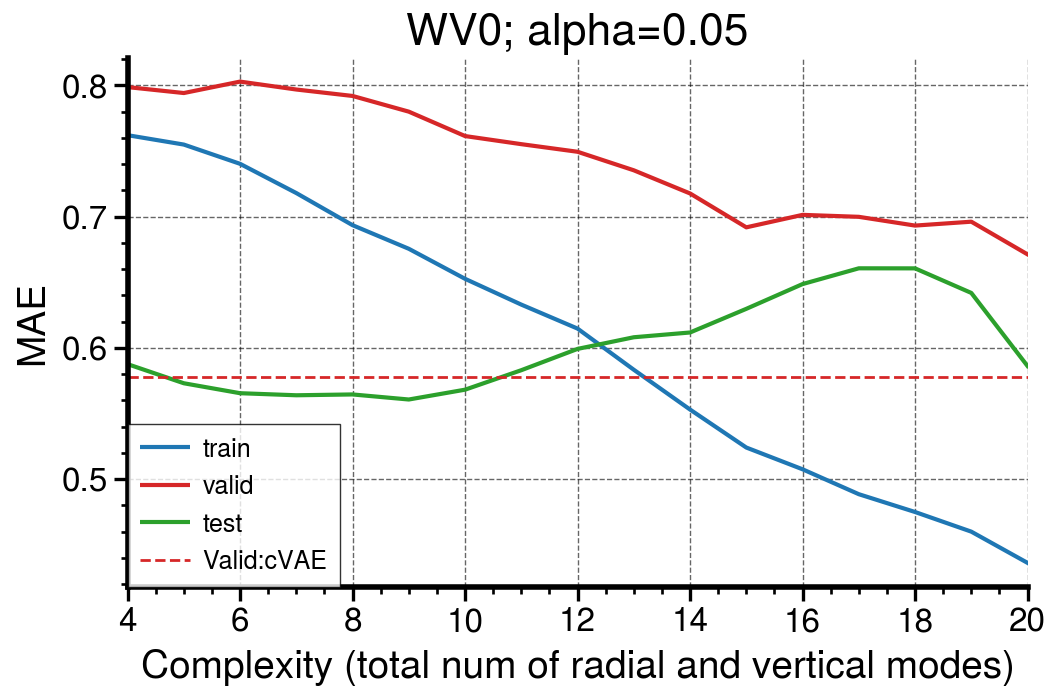

In [15]:
fig, ax = plot.subplots(refwidth=4.5, refaspect=1.7)
colors = ['tab:blue','tab:red','tab:green']
for ind,datatype in enumerate(['train','valid','test']):
    final_result,_ = _get_complexity_(lassoalpha=0.05,TYPE=datatype,metric='MAE')
    ax.plot(list(final_result.keys()),[final_result[key] for key in final_result.keys()],label=datatype,c=colors[ind])
#ax.axhline(y=0.9199999999999999,lw=1,ls='--',c='tab:green',label='Test:cVAE')
ax.axhline(y=0.5780000000000001,lw=1,ls='--',c='tab:red',label='Valid:cVAE')
# Style & labels (ProPlot uses similar syntax to matplotlib)
ax.format(
    xlabel='Complexity (total num of radial and vertical modes)',
    ylabel='MAE',
    title=f'WV0; alpha=0.05',
    xlabelsize=14,
    ylabelsize=14,
    titlesize=16,
    ticklabelsize=12,
    grid=True,
    gridstyle='--',
    gridalpha=0.6,
    ticklen=5,
    tickwidth=1.2
)

# Optional: hide top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Make top and left spines thicker
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
# Legend
ax.legend(fontsize=12,ncols=1)
plt.savefig('./pics/decomp/wv0_alpha0.05_complexity.png',dpi=400)
plt.show()

In [105]:
_,complexity = _get_complexity_(lassoalpha=0.3,TYPE='valid',metric='MAE')

Select (rad,vert)=(5,10) from complexity